Name: **Stephane Chambrelain Talla Fotsing**  
Student Number: **ST139766**  
Program: **Data Analytics and Artificial Intelligence**  
Course - **Introduction to Artificial Intelligence**  
**Assignment 12: Neural Network and Deep Learning Basics**

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Input, Flatten, Dense
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay)

## 1. Dataset Preparation

**- Load the dataset**

In [2]:
(X_train, y_train), (X_test, y_test) = (tf.keras.datasets.cifar10.load_data())
# Convert labels into one-dimensional arrays
y_train = y_train.flatten()
y_test = y_test.flatten()
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck"]
print("Training images:", X_train.shape)
print("Testing images:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 1761s 10us/step
Training images: (50000, 32, 32, 3)
Testing images: (10000, 32, 32, 3)
Training labels: (50000,)
Testing labels: (10000,)


**- Visualize three images from each class**

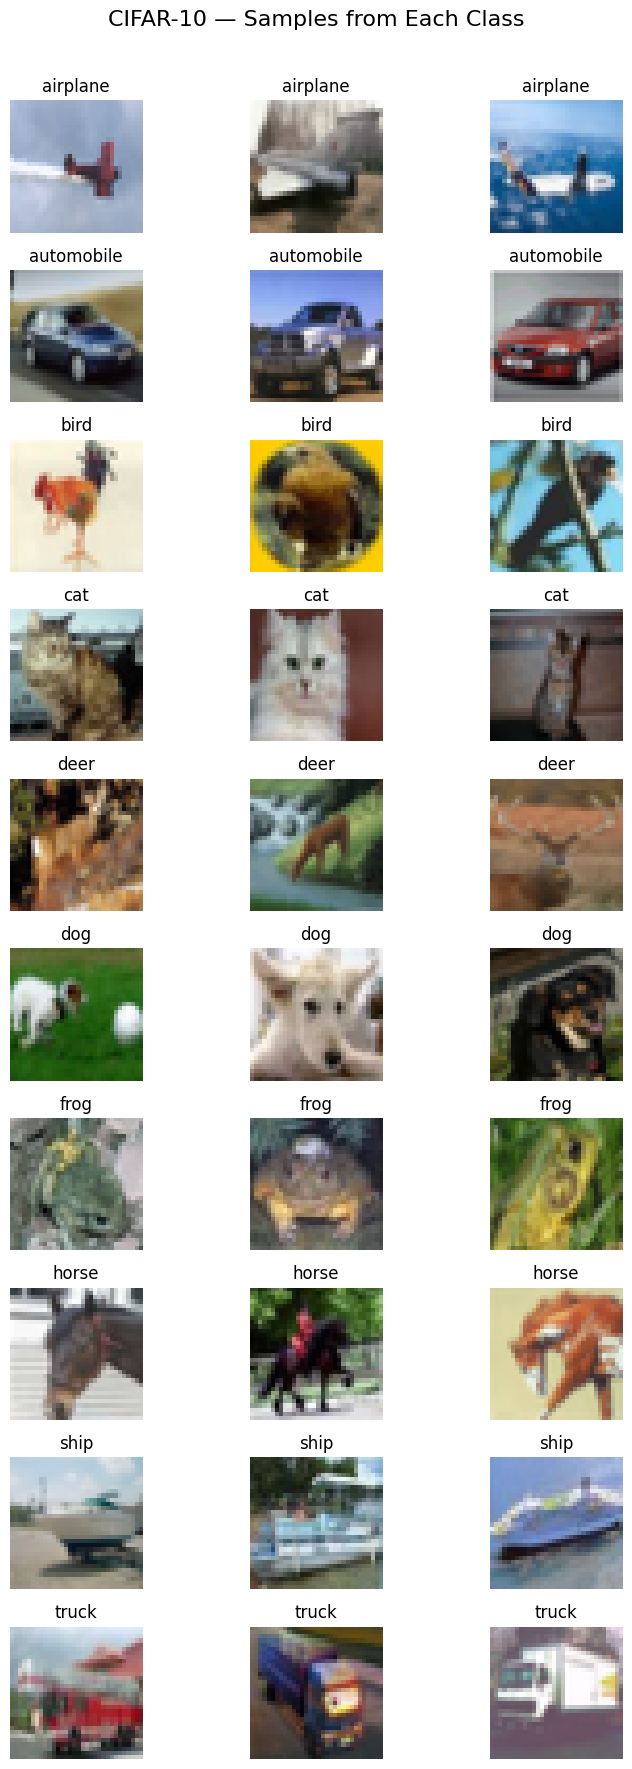

In [3]:
rng = np.random.default_rng(42)
fig, axes = plt.subplots(10, 3, figsize=(8, 18))
for class_id, class_name in enumerate(class_names):
    class_indices = np.where(y_train == class_id)[0]
    sample_indices = rng.choice(class_indices, size=3, replace=False)
    for column, image_index in enumerate(sample_indices):
        axes[class_id, column].imshow(X_train[image_index])
        axes[class_id, column].set_title(class_name)
        axes[class_id, column].axis("off")
plt.suptitle("CIFAR-10 — Samples from Each Class", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 2. Image Preprocessing

**- Normalize the images**

In [4]:
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0
print("Training pixel range:", X_train.min(), "to", X_train.max())
print("Testing pixel range:", X_test.min(), "to", X_test.max())

Training pixel range: 0.0 to 1.0
Testing pixel range: 0.0 to 1.0


**- Apply optional data augmentation**

In [7]:
datagen = ImageDataGenerator(rotation_range=15, width_shift_range=0.1, height_shift_range=0.1,
    zoom_range=0.1, horizontal_flip=True, fill_mode="nearest")

**- Preview augmented images**

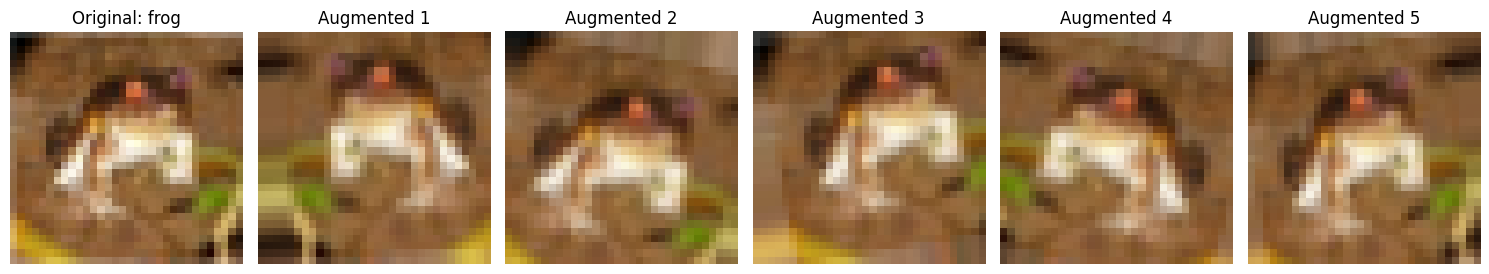

In [8]:
image = X_train[0]
label = class_names[y_train[0]]
augmented_images = datagen.flow(image[np.newaxis, ...], batch_size=1, shuffle=False, seed=42)
fig, axes = plt.subplots(1, 6, figsize=(15, 3))
# Set the axes
axes[0].imshow(image)
axes[0].set_title(f"Original: {label}")
axes[0].axis("off")
# Iterate through augmented_images
for i in range(1, 6):
    augmented_image = next(augmented_images)[0]
    axes[i].imshow(np.clip(augmented_image, 0, 1))
    axes[i].set_title(f"Augmented {i}")
    axes[i].axis("off")
# Display
plt.tight_layout()
plt.show()

## 3. Neural Network Implementation

**- Prepare training and validation data**

In [9]:
tf.keras.utils.set_random_seed(42)
X_fit, X_val, y_fit, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=42, stratify=y_train)
y_fit_encoded = to_categorical(y_fit, num_classes=10)
y_val_encoded = to_categorical(y_val, num_classes=10)
print("Training images:", X_fit.shape)
print("Validation images:", X_val.shape)

Training images: (40000, 32, 32, 3)
Validation images: (10000, 32, 32, 3)


**- Build the neural network**

In [10]:
model = Sequential([
Input(shape=(32, 32, 3)), Flatten(), Dense(256, activation="relu"),
    Dense(128, activation="relu"), Dense(10, activation="softmax")
])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
# Compile the model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train the model
train_generator = datagen.flow(X_fit, y_fit_encoded, batch_size=64, shuffle=True, seed=42)
history = model.fit(train_generator, epochs=15, validation_data=(X_val, y_val_encoded))

Epoch 1/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 58ms/step - accuracy: 0.2951 - loss: 1.9495 - val_accuracy: 0.3754 - val_loss: 1.7543
Epoch 2/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.3507 - loss: 1.8045 - val_accuracy: 0.3797 - val_loss: 1.7169
Epoch 3/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 38s 61ms/step - accuracy: 0.3731 - loss: 1.7475 - val_accuracy: 0.4248 - val_loss: 1.6311
Epoch 4/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.3898 - loss: 1.6924 - val_accuracy: 0.4320 - val_loss: 1.5900
Epoch 5/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 34s 55ms/step - accuracy: 0.4009 - loss: 1.6678 - val_accuracy: 0.4359 - val_loss: 1.6012
Epoch 6/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 57ms/step - accuracy: 0.4098 - loss: 1.6490 - val_accuracy: 0.4484 - val_loss: 1.5606
Epoch 7/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.4150 - loss: 1.6313 - val_accuracy: 0.4460 - val_loss: 1.5473
Epoch 8/15
625/625 ━━━━━━━━━━━━━━━━━━━━ 35s 56ms/step - accuracy: 0.4203 - loss: 1.6144 - 

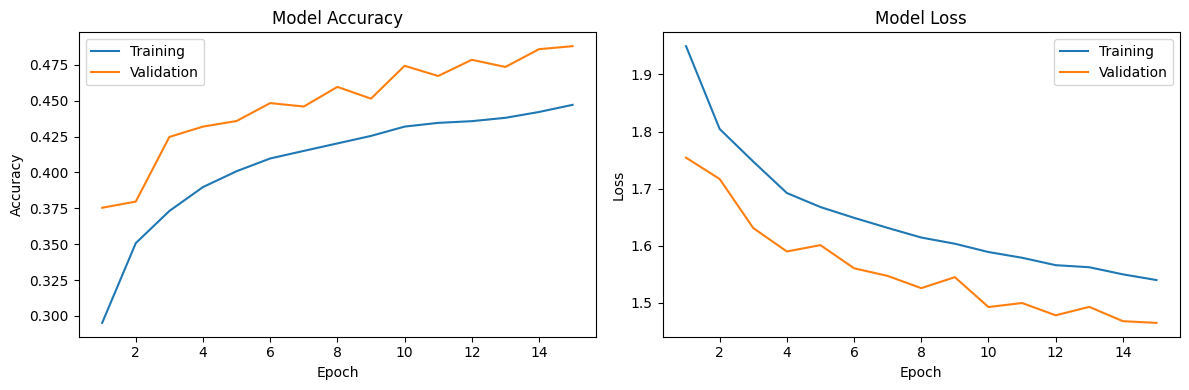

In [12]:
# Plot training and validation performance
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = range(1, len(history.history["loss"]) + 1)
axes[0].plot(epochs, history.history["accuracy"], label="Training")
axes[0].plot(epochs, history.history["val_accuracy"], label="Validation")
axes[0].set_title("Model Accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()
axes[1].plot(epochs, history.history["loss"], label="Training")
axes[1].plot(epochs, history.history["val_loss"], label="Validation")
axes[1].set_title("Model Loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. Model Evaluation

In [16]:
# Evaluate the current model on the test set
y_prob = model.predict(X_test, batch_size=64)
y_pred = np.argmax(y_prob, axis=1)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1-score:  {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")

157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
Accuracy:  0.4765
Precision: 0.4700
Recall:    0.4765
F1-score:  0.4681


In [17]:
# Display the classification report
print(
    classification_report(y_test,y_pred, labels=np.arange(10),target_names=class_names, digits=4, zero_division=0
))

              precision    recall  f1-score   support

    airplane     0.4958    0.5960    0.5413      1000
  automobile     0.5344    0.6450    0.5845      1000
        bird     0.4334    0.2700    0.3327      1000
         cat     0.3333    0.2650    0.2953      1000
        deer     0.4686    0.3730    0.4154      1000
         dog     0.3824    0.4030    0.3924      1000
        frog     0.4774    0.5820    0.5246      1000
       horse     0.5242    0.5100    0.5170      1000
        ship     0.5301    0.6510    0.5844      1000
       truck     0.5205    0.4700    0.4940      1000

    accuracy                         0.4765     10000
   macro avg     0.4700    0.4765    0.4681     10000
weighted avg     0.4700    0.4765    0.4681     10000



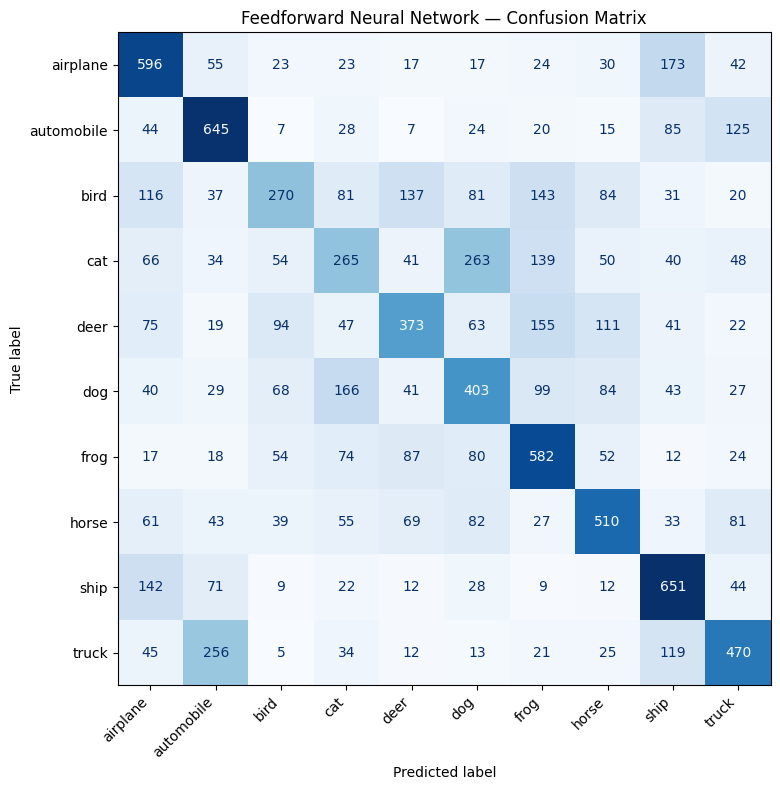

In [18]:
# Visualize the confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=np.arange(10))
fig, ax = plt.subplots(figsize=(10, 8))
cm_display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
cm_display.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
# Title & label
ax.set_title("Feedforward Neural Network — Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 5. Application Demonstration

The trained CIFAR-10 model could help a photo management application automatically tag images as airplanes, automobiles, birds, cats, deer, dogs, frogs, horses, ships, or trucks. Users could then search their photo collections by category.

When a user uploads a photo, the application would resize it to 32 × 32 pixels, normalize its pixel values to 0–1, and pass it to the model. The predicted category would be stored as a suggested tag that the user could confirm or correct.

Operational considerations include accuracy, scalability, processing speed, integration, and privacy. With a test accuracy of 47.65%, the model’s suggested tags should be reviewed by users. Large photo collections could be processed in batches, while individual uploads could receive immediate predictions if response times are acceptable. An API could connect the model to an existing photo application and store its predictions in a database. However, the model assigns only one of ten known classes, which limits its usefulness for photos containing multiple objects or unfamiliar categories. Uploaded photos should also be protected through secure storage and restricted access.

In [1]:
!find "/content/drive/MyDrive" -iname "Assignment_12.ipynb"

find: ‘/content/drive/MyDrive’: No such file or directory


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
!ls -la /content/colab-git-assignment2-ST

ls: cannot access '/content/colab-git-assignment2-ST': No such file or directory


In [4]:
!git clone https://github.com/StephaneTF/colab-git-assignment2-ST.git /content/colab-git-assignment2-ST

Cloning into '/content/colab-git-assignment2-ST'...
remote: Enumerating objects: 85, done.
remote: Counting objects: 100% (85/85), done.
remote: Compressing objects: 100% (70/70), done.
remote: Total 85 (delta 31), reused 32 (delta 7), pack-reused 0 (from 0)
Receiving objects: 100% (85/85), 3.23 MiB | 16.88 MiB/s, done.
Resolving deltas: 100% (31/31), done.


In [5]:
!ls -la /content/colab-git-assignment2-ST

total 3792
drwxr-xr-x 8 root root    4096 Sep 19 09:40  .
drwxr-xr-x 1 root root    4096 Sep 19 09:40  ..
drwxr-xr-x 2 root root    4096 Sep 19 09:40  Assignment_13
drwxr-xr-x 2 root root    4096 Sep 19 09:40  Assignment_14
-rw-r--r-- 1 root root  490404 Sep 19 09:40  Assignment_15.ipynb
-rw-r--r-- 1 root root    5415 Sep 19 09:40  assignment2.ipynb
drwxr-xr-x 2 root root    4096 Sep 19 09:40  Assignment_8
drwxr-xr-x 2 root root    4096 Sep 19 09:40  Assignment_9
drwxr-xr-x 8 root root    4096 Sep 19 09:40  .git
drwxr-xr-x 2 root root    4096 Sep 19 09:40  Lesson_10_assignment
-rw-r--r-- 1 root root   12704 Sep 19 09:40  Lesson_3_assignment.ipynb
-rw-r--r-- 1 root root   80271 Sep 19 09:40 'Lesson 4 assignment.ipynb'
-rw-r--r-- 1 root root  549515 Sep 19 09:40  Lesson_5_Assignment.ipynb
-rw-r--r-- 1 root root 2321005 Sep 19 09:40  Lesson_6_ml_basic_assignment.ipynb
-rw-r--r-- 1 root root  376413 Sep 19 09:40  Lesson_7_assignment.ipynb
